# HDD benchmark: DOB + IIR-MMP reconstruction

This notebook estimates the fan disturbance using the DOB output, applies high-pass filtering, reconstructs beyond-Nyquist components using the IIR-MMP, and generates time-domain, FFT, and MMP Bode plots.

## 1. Imports and Functions

In [3]:
import os
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# plotting parameters and export
mpl.rcParams['font.family'] = 'Times New Roman'
mpl.rcParams['mathtext.fontset'] = 'stix'   # makes math look Times-like
mpl.rcParams['font.size'] = 12
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 12
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['xtick.labelsize'] = 11
mpl.rcParams['ytick.labelsize'] = 11
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

from scipy import signal
import control as ct
import control.matlab as ctm
import plant
import utils
import function_simulation_combined

# import functions
from function_simulation_combined import Function_simulation
from mfmdob_functions import signal_recovery_iir, mmp_coeff

###### helper functions ######
def as_1d(x):
    """Convert an input to a one-dimensional NumPy array."""
    return np.asarray(x).squeeze()


def trim_to_common_length(*signals):
    """Trim all signals to the minimum common length."""
    arrays = [as_1d(sig) for sig in signals]
    n = min(len(arr) for arr in arrays)
    return [arr[:n] for arr in arrays], n


def save_current_figure(filename):
    """Save the current Matplotlib figure if SAVE_FIGURES is enabled."""
    if SAVE_FIGURES:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        plt.savefig(FIG_DIR / filename, bbox_inches='tight')


def make_time_mask(t, start=None, duration=None, end=None):
    """Create a robust time-window mask.

    If the requested start time is outside the signal, the function falls back
    to the first 20% point of the signal so the plot is not empty.
    """
    t = as_1d(t)
    if len(t) == 0:
        raise ValueError("Time vector is empty.")

    if start is None:
        start = t[0]

    if start >= t[-1]:
        start = t[0] + 0.2 * (t[-1] - t[0])

    if end is None:
        end = t[-1] if duration is None else start + duration

    end = min(end, t[-1])
    mask = (t >= start) & (t <= end)

    if not np.any(mask):
        raise ValueError(
            f"No points selected for window [{start:.6e}, {end:.6e}] "
            f"within signal range [{t[0]:.6e}, {t[-1]:.6e}]."
        )

    return mask, (start, end)


def relative_rms_error(y_true, y_est):
    """Return RMS error, true RMS, relative error, and fit percentage."""
    y_true, y_est = trim_to_common_length(y_true, y_est)[0]
    rms_err = np.sqrt(np.mean((y_true - y_est) ** 2))
    rms_true = np.sqrt(np.mean(y_true ** 2))
    rel_err = rms_err / rms_true
    fit = 100 * (1 - rel_err)
    return rms_err, rms_true, rel_err, fit


def fft_mag_db(x, fs):
    """One-sided FFT magnitude in dB."""
    x = as_1d(x)
    if len(x) == 0:
        raise ValueError("Cannot compute FFT of an empty signal.")

    x = x - np.mean(x)
    n = len(x)
    freq = np.fft.rfftfreq(n, d=1 / fs)
    X = np.fft.rfft(x)
    mag_db = 20 * np.log10(np.abs(X) / n + 1e-30)
    return freq, mag_db


def draw_frequency_lines(frequencies, ax=None, label_y=0.01):
    """Draw vertical frequency markers with labels."""
    if ax is None:
        ax = plt.gca()

    for freq_hz in frequencies:
        ax.axvline(freq_hz, color='k', linestyle=':', alpha=0.35)
        ax.text(
            freq_hz,
            label_y,
            f'{freq_hz:.0f}',
            rotation=90,
            fontsize=10,
            fontweight='bold',
            color='k',
            alpha=0.85,
            transform=ax.get_xaxis_transform(),
            ha='center',
            va='bottom'
        )

def draw_nyquist(F_NYQUIST_SLOW, ax=None):
    """Draw Nyquist frequency marker."""
    if ax is None:
        ax = plt.gca()

    ax.axvline(
        F_NYQUIST_SLOW,
        color='r',
        linestyle='--',
        linewidth=2,
        label=f'Nyquist = {F_NYQUIST_SLOW:.0f} Hz'
    )

def peak_match_metrics(y_true, y_est, fs, f_targets, band_hz=20):
    """
    Compare spectral peak amplitudes near target frequencies.

    y_true: true disturbance
    y_est: reconstructed/estimated disturbance
    fs: sampling frequency [Hz]
    f_targets: target frequencies [Hz]
    band_hz: search band around each target frequency
    """

    y_true = np.asarray(y_true).squeeze()
    y_est = np.asarray(y_est).squeeze()

    N = min(len(y_true), len(y_est))
    y_true = y_true[:N] - np.mean(y_true[:N])
    y_est = y_est[:N] - np.mean(y_est[:N])

    freq = np.fft.rfftfreq(N, d=1/fs)

    Y_true = np.fft.rfft(y_true)
    Y_est = np.fft.rfft(y_est)

    mag_true = 2*np.abs(Y_true)/N
    mag_est = 2*np.abs(Y_est)/N

    results = []

    for f0 in f_targets:
        idx_band = np.where((freq >= f0-band_hz) & (freq <= f0+band_hz))[0]

        if len(idx_band) == 0:
            continue

        idx_true_peak = idx_band[np.argmax(mag_true[idx_band])]
        idx_est_peak = idx_band[np.argmax(mag_est[idx_band])]

        amp_true = mag_true[idx_true_peak]
        amp_est = mag_est[idx_est_peak]

        amp_error = amp_est - amp_true
        amp_error_pct = 100 * amp_error / (amp_true + 1e-30)
        amp_error_db = 20*np.log10((amp_est + 1e-30)/(amp_true + 1e-30))

        results.append({
            "target_hz": f0,
            "true_peak_hz": freq[idx_true_peak],
            "est_peak_hz": freq[idx_est_peak],
            "true_amp": amp_true,
            "est_amp": amp_est,
            "amp_error": amp_error,
            "amp_error_pct": amp_error_pct,
            "amp_error_db": amp_error_db
        })

    return results

def peak_to_noise_ratio(y, fs, f_targets, peak_band_hz=20, noise_band_hz=300, guard_hz=40):
    """
    Compute peak-to-noise ratio around target frequencies.

    Uses local median noise floor around each target frequency.
    """

    y = np.asarray(y).squeeze()
    y = y - np.mean(y)

    N = len(y)
    freq = np.fft.rfftfreq(N, d=1/fs)
    Y = np.fft.rfft(y)
    mag = 2*np.abs(Y)/N

    results = []

    for f0 in f_targets:
        peak_idx = np.where((freq >= f0-peak_band_hz) & (freq <= f0+peak_band_hz))[0]

        noise_idx = np.where(
            (freq >= f0-noise_band_hz) &
            (freq <= f0+noise_band_hz) &
            ~((freq >= f0-guard_hz) & (freq <= f0+guard_hz))
        )[0]

        if len(peak_idx) == 0 or len(noise_idx) == 0:
            continue

        peak_amp = np.max(mag[peak_idx])
        noise_floor = np.median(mag[noise_idx])

        pnr_db = 20*np.log10((peak_amp + 1e-30)/(noise_floor + 1e-30))

        results.append({
            "target_hz": f0,
            "peak_amp": peak_amp,
            "noise_floor": noise_floor,
            "pnr_db": pnr_db
        })

    return results

def choose_coherence_nperseg(y1, y2, desired=1024, min_segments=4):
    """
    Choose nperseg so coherence uses multiple segments.
    """
    N = min(len(np.asarray(y1).squeeze()), len(np.asarray(y2).squeeze()))

    # Force at least min_segments segments
    max_nperseg = N // min_segments

    nperseg = min(desired, max_nperseg)

    # Keep it reasonable
    nperseg = max(256, nperseg)

    return nperseg

def choose_hp_filter(RAW_SIGNAL, HP_ORDER, HP_CUTOFF_HZ, FS_FAST, FILTER_MODE='online'):
    """
    choose online or offline filtering.
    Different filters, use lfilter() or sosfilt() for online; filtfilt or sosfiltfilt for offline

    # other filters
        # High-pass difference filter: y[n] = x[n] - x[n-1]
        b_hp = np.array([1, -1])
        a_hp = np.array([1])
        
        # Elliptic high-pass
        b, a = signal.ellip(4, 0.5, 40, fc, btype='highpass', fs=fs_fast)
        dhat_p_hp = signal.lfilter(b, a, dhat_p) 
        
        # Chebyshev high-pass
        b, a = signal.cheby1(4, 0.5, fc, btype='highpass', fs=fs_fast)
        dhat_p_hp = signal.lfilter(b, a, dhat_p)
    """
    if FILTER_MODE == 'offline':
        sos_hp = signal.butter(
        N=HP_ORDER,
        Wn=HP_CUTOFF_HZ,
        btype='highpass',
        fs=FS_FAST,
        output='sos'
        )
        filtered_signal = signal.sosfiltfilt(sos_hp, RAW_SIGNAL)
        print('Applied offline zero-phase high-pass filter')
    elif FILTER_MODE == 'online':
        sos_hp = signal.butter(
            N=HP_ORDER,
            Wn=HP_CUTOFF_HZ,
            btype='highpass',
            fs=FS_FAST,
            output='sos'
        )
        filtered_signal = signal.sosfilt(sos_hp, RAW_SIGNAL)
        print('Applied online casual high-pass filter')
    else:
        raise ValueError("FILTER_MODE must be 'online' or 'offline'")
    return filtered_signal        


     ______          _     _  _____    _____   
    (_____ \        | |   | |(____ \  (____ \  
     _____) ) _   _ | |__ | | _   \ \  _   \ \ 
    |  ____/ | | | ||  __)| || |   | || |   | |
    | |      | |_| || |   | || |__/ / | |__/ / 
    |_|       \__  ||_|   |_||_____/  |_____/  
              (____/                            
    
(v0.1.0)


C:\ProgramData\anaconda3\Lib\site-packages\scipy\signal\_filter_design.py:1746: BadCoefficients: Badly conditioned filter coefficients (numerator): the results may be meaningless
  warnings.warn("Badly conditioned filter coefficients (numerator): the "


## 2. Run benchmark simulation

In [62]:
# Simulation case
# Cases 1-9
# cases 1 - 3 (nominal PZT gain variations). 1(LT), 2(RT), 3(HT)
# cases 4 - 6 (nominal +5%). 4(LT), 5(RT), 6(HT)
# cases 7 - 9 (nominal -5%). 7(LT), 8(RT), 9(HT) 

SIM_CASE = 2
FAN_NOISE_TYPE = "random"   # choose "random" or "sinusoidal"

sim_result = function_simulation_combined.run_case(
    SIM_CASE,
    fan_noise_type=FAN_NOISE_TYPE,
    output_suffix=FAN_NOISE_TYPE
)

Running case 2 with fan_noise_type='random'...
case 2 finishedtion: process 2 sim progress: 99.2%


## 3. Global settings

In [65]:
# Sampling settings
TS = plant.Ts
FS_PLANT = 1 / TS
MR_F = plant.Mr_f
MR_P = 20
TS_FAST = TS / MR_F
FS_FAST = 1 / TS_FAST
STEP_SIM_TO_FAST = int(MR_P / MR_F)

# MMP settings
L_MMP = 6
A_G = 0.94
if FAN_NOISE_TYPE == "sinusoidal":
#    F_MMP = np.array([5072, 5850, 7670, 9200], dtype=float)
    F_MMP = np.array([5072, 5850, 7670, 9200], dtype=float)
elif FAN_NOISE_TYPE == "random":
    F_MMP = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200], dtype=float)
    #F_MMP = np.array([9200], dtype=float)
else:
    raise ValueError("FAN_NOISE_TYPE must be 'sinusoidal' or 'random'")
F_DIST_ALL = np.array([2200, 2937, 3300, 3545, 3980, 4220, 4380, 5072, 5370, 5850, 6660, 7670, 9200], dtype=float)

FS_SLOW = FS_FAST / L_MMP
F_NYQUIST_SLOW = FS_SLOW / 2

# High-pass filter settings
HP_ORDER = 3
HP_CUTOFF_HZ = 1000
FILTER_MODE = 'offline' # choose online or offline filter mode

# Plotting and metrics settings
T_RMS_START = 0.05
T_PLOT_START = 0.05
T_PLOT_DURATION = 4e-3
FFT_XLIM_FULL = (1000, 50000)
FFT_XLIM_ZOOM = (4000, 10000)
BODE_XLIM = (0, 10000)

# Output settings
SAVE_FIGURES = True
FIG_DIR = Path("plot_result")

print(f"Plant/controller sampling frequency = {FS_PLANT/1000:.1f} kHz")
print(f"Fast multirate sampling frequency = {FS_FAST/1000:.1f} kHz")
print(f"Sparse MMP sampling frequency = {FS_SLOW/1000:.1f} kHz")
print(f"Slow-rate Nyquist frequency = {F_NYQUIST_SLOW/1000:.1f} kHz")
print(f"Simulation-to-fast downsample step = {STEP_SIM_TO_FAST}")


Plant/controller sampling frequency = 50.4 kHz
Fast multirate sampling frequency = 100.8 kHz
Sparse MMP sampling frequency = 16.8 kHz
Slow-rate Nyquist frequency = 8.4 kHz
Simulation-to-fast downsample step = 10


## 4. DOB output estimation and high-pass filtering

In [68]:
# System models
Sys_Fm_pzt = utils.get_Sys_Fm_pzt()
Sys_Fm_vcm = utils.get_Sys_Fm_vcm()
Sys_Pc_pzt = plant.Sys_Pc_pzt_c2
Sys_Pc_vcm = plant.Sys_Pc_vcm_c2

# Discretize continuous plants at the fast multirate sampling period
Sys_Ppzt_d = ctm.c2d(ctm.ss(Sys_Pc_pzt), TS_FAST)
Sys_Pvcm_d = ctm.c2d(ctm.ss(Sys_Pc_vcm), TS_FAST)

# DOB model paths: controller output -> multirate filter -> plant
Sys_pzt_dob = Sys_Ppzt_d * Sys_Fm_pzt
Sys_vcm_dob = Sys_Pvcm_d * Sys_Fm_vcm

# Simulation outputs, downsampled from the internal simulation grid to the fast grid
yc = as_1d(sim_result['yc'])[::STEP_SIM_TO_FAST]
yc_pzt = as_1d(sim_result['yc_pzt'])[::STEP_SIM_TO_FAST]
yc_vcm = as_1d(sim_result['yc_vcm'])[::STEP_SIM_TO_FAST]
d_p = as_1d(sim_result['dp'])[::STEP_SIM_TO_FAST]
d_f = as_1d(sim_result['df'])[::STEP_SIM_TO_FAST]
ud_pzt = as_1d(sim_result['ud_pzt'])[::STEP_SIM_TO_FAST]
ud_vcm = as_1d(sim_result['ud_vcm'])[::STEP_SIM_TO_FAST]

(yc, yc_pzt, yc_vcm, d_p, d_f, ud_pzt, ud_vcm), N_FAST = trim_to_common_length(
    yc, yc_pzt, yc_vcm, d_p, d_f, ud_pzt, ud_vcm
)
t_fast = np.arange(N_FAST) * TS_FAST

# Simulate modeled actuator contributions
# PZT: yhat_pzt = P_pzt * F_pzt * u_pzt
# VCM: yhat_vcm = P_vcm * F_vcm * u_vcm
# Known VCM disturbance contribution for diagnostic comparison: y_df = P_vcm * d_f
yhat_pzt, _, _ = ctm.lsim(Sys_pzt_dob, U=ud_pzt, T=t_fast)
yhat_vcm, _, _ = ctm.lsim(Sys_vcm_dob, U=ud_vcm, T=t_fast)
y_df, _, _ = ctm.lsim(Sys_Pvcm_d, U=d_f, T=t_fast)

yhat_pzt = as_1d(yhat_pzt)
yhat_vcm = as_1d(yhat_vcm)
y_df = as_1d(y_df)

(yc, yc_pzt, yc_vcm, d_p, d_f, ud_pzt, ud_vcm, yhat_pzt, yhat_vcm, y_df), N_FAST = trim_to_common_length(
    yc, yc_pzt, yc_vcm, d_p, d_f, ud_pzt, ud_vcm, yhat_pzt, yhat_vcm, y_df
)
t_fast = np.arange(N_FAST) * TS_FAST

# DOB estimate of fan disturbance.
# This removes modeled PZT and VCM controller-path contributions.
# The VCM disturbance d_f is not subtracted here because it is unknown in the real case.
dhat_p_raw = yc - yhat_pzt - yhat_vcm

# apply HP filter
dhat_p_hp = choose_hp_filter(dhat_p_raw, HP_ORDER, HP_CUTOFF_HZ, FS_FAST, FILTER_MODE)

# DOB error after high-pass filtering
rms_mask, rms_window = make_time_mask(t_fast, start=T_RMS_START)
rms_err_hp, rms_true, rel_err_hp, fit_hp = relative_rms_error(
    d_p[rms_mask],
    dhat_p_hp[rms_mask]
)

print(f"DOB high-pass window = [{rms_window[0]:.4f}, {rms_window[1]:.4f}] s")
print(f"DOB RMS error after HP = {rms_err_hp:.6e}")
print(f"DOB relative RMS error after HP = {100 * rel_err_hp:.3f}%")
print(f"DOB fit after HP = {fit_hp:.3f}%")

Applied offline zero-phase high-pass filter
DOB high-pass window = [0.0500, 1.0000] s
DOB RMS error after HP = 3.788032e-10
DOB relative RMS error after HP = 13.230%
DOB fit after HP = 86.770%


## 5. DOB diagnostic plots

Plot window = [0.050000, 0.054000] s


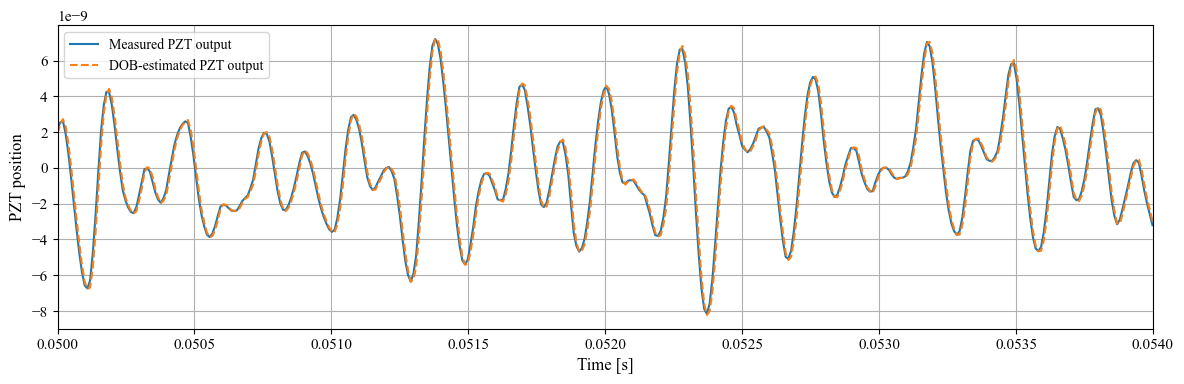

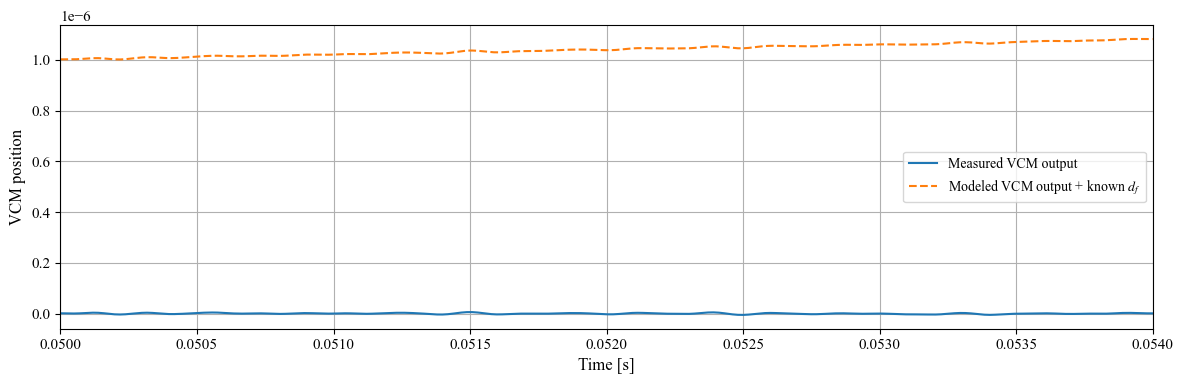

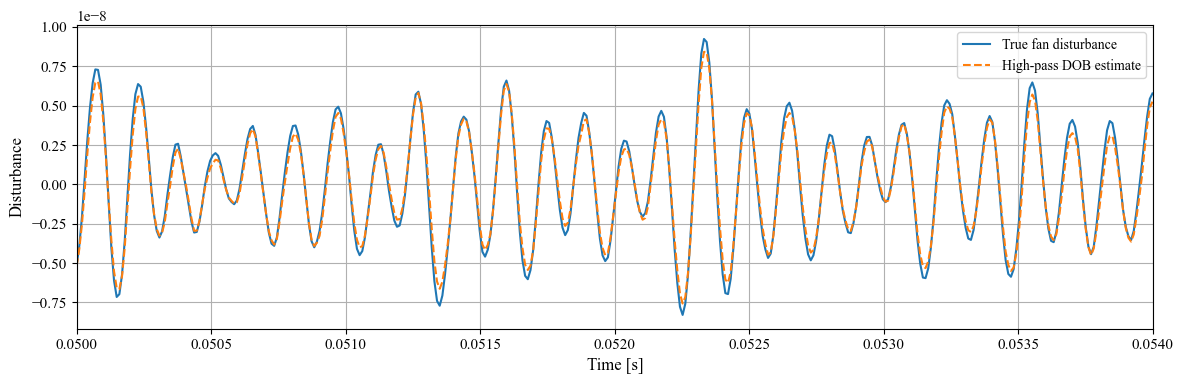

In [70]:
plot_mask, plot_window = make_time_mask(
    t_fast,
    start=T_PLOT_START,
    duration=T_PLOT_DURATION
)
print(f"Plot window = [{plot_window[0]:.6f}, {plot_window[1]:.6f}] s")
plot_xlim = [plot_window[0], plot_window[1]]


# PZT output comparison
plt.figure(figsize=(12, 4))
plt.plot(t_fast[plot_mask], yc_pzt[plot_mask], label='Measured PZT output')
plt.plot(t_fast[plot_mask], yhat_pzt[plot_mask], '--', label='DOB-estimated PZT output')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('PZT position')
plt.xlim(plot_xlim)
plt.tight_layout()
plt.show()

# VCM output comparison
plt.figure(figsize=(12, 4))
plt.plot(t_fast[plot_mask], yc_vcm[plot_mask], label='Measured VCM output')
plt.plot(t_fast[plot_mask], (yhat_vcm + y_df)[plot_mask], '--', label='Modeled VCM output + known $d_f$')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('VCM position')
plt.xlim(plot_xlim)
plt.tight_layout()
plt.show()

# True fan disturbance vs high-pass DOB estimate
plt.figure(figsize=(12, 4))
plt.plot(t_fast[plot_mask], d_p[plot_mask], label='True fan disturbance')
plt.plot(t_fast[plot_mask], dhat_p_hp[plot_mask], '--', label='High-pass DOB estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.xlim(plot_xlim)
plt.tight_layout()
plt.show()

## 6. IIR-MMP reconstruction from sparse samples

In [74]:
# Downsample from 100.8 kHz to 16.8 kHz for the sparse MMP input.
dhat_p_slow = dhat_p_hp[::L_MMP]
dp_slow = d_p[::L_MMP]

# IIR-MMP reconstruction using sparse true disturbance and sparse DOB-estimated disturbance.
dp_mmp = signal_recovery_iir(
    input_signal=dp_slow,
    f_hz=F_MMP,
    t_fs=TS_FAST,
    a_g=A_G,
    L=L_MMP
)

dhat_mmp = signal_recovery_iir(
    input_signal=dhat_p_slow,
    f_hz=F_MMP,
    t_fs=TS_FAST,
    a_g=A_G,
    L=L_MMP
)

# Align signals after reconstruction without overwriting the original arrays.
(d_p_ref, dhat_p_hp_ref, dp_mmp, dhat_mmp), N_MMP = trim_to_common_length(
    d_p,
    dhat_p_hp,
    dp_mmp,
    dhat_mmp
)
t_mmp = np.arange(N_MMP) * TS_FAST

# Steady-state error metrics
ss_mask, ss_window = make_time_mask(t_mmp, start=T_RMS_START)

rms_err_true_mmp, rms_true, rel_err_true_mmp, fit_true_mmp = relative_rms_error(
    d_p_ref[ss_mask],
    dp_mmp[ss_mask]
)

rms_err_dob_mmp, _, rel_err_dob_mmp, fit_dob_mmp = relative_rms_error(
    d_p_ref[ss_mask],
    dhat_mmp[ss_mask]
)

print(f"MMP steady-state window = [{ss_window[0]:.4f}, {ss_window[1]:.4f}] s")
print(f"MMP RMS error using sparse true disturbance = {rms_err_true_mmp:.6e}")
print(f"MMP relative RMS error using sparse true disturbance = {100 * rel_err_true_mmp:.3f}%")
print(f"MMP fit using sparse true disturbance = {fit_true_mmp:.3f}%")
print()
print(f"MMP RMS error using sparse DOB estimate = {rms_err_dob_mmp:.6e}")
print(f"MMP relative RMS error using sparse DOB estimate = {100 * rel_err_dob_mmp:.3f}%")
print(f"MMP fit using sparse DOB estimate = {fit_dob_mmp:.3f}%")


MMP steady-state window = [0.0500, 0.9999] s
MMP RMS error using sparse true disturbance = 1.675973e-09
MMP relative RMS error using sparse true disturbance = 58.532%
MMP fit using sparse true disturbance = 41.468%

MMP RMS error using sparse DOB estimate = 1.661939e-09
MMP relative RMS error using sparse DOB estimate = 58.042%
MMP fit using sparse DOB estimate = 41.958%


## 7. MMP time-domain and FFT plots

MMP plot window = [0.050000, 0.054000] s


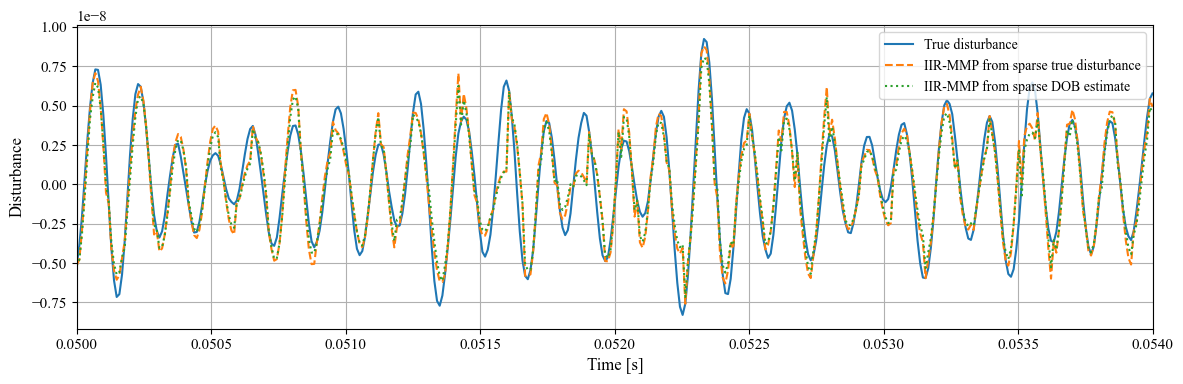

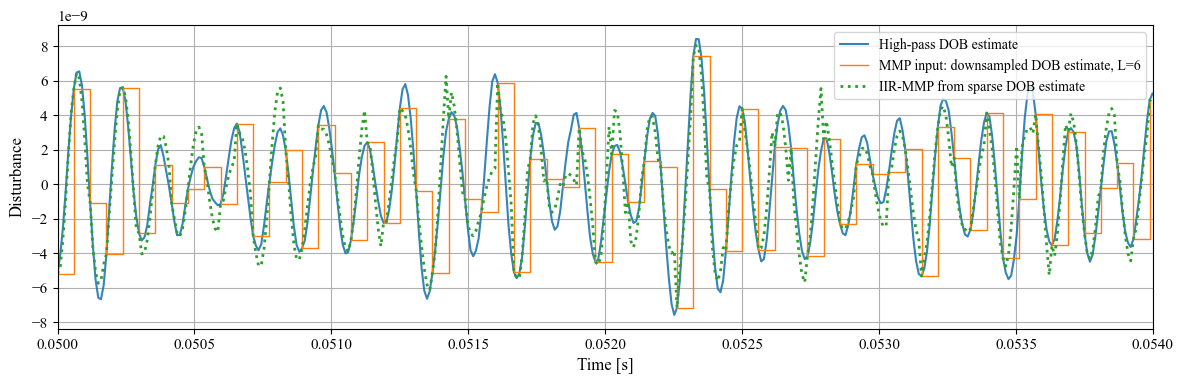

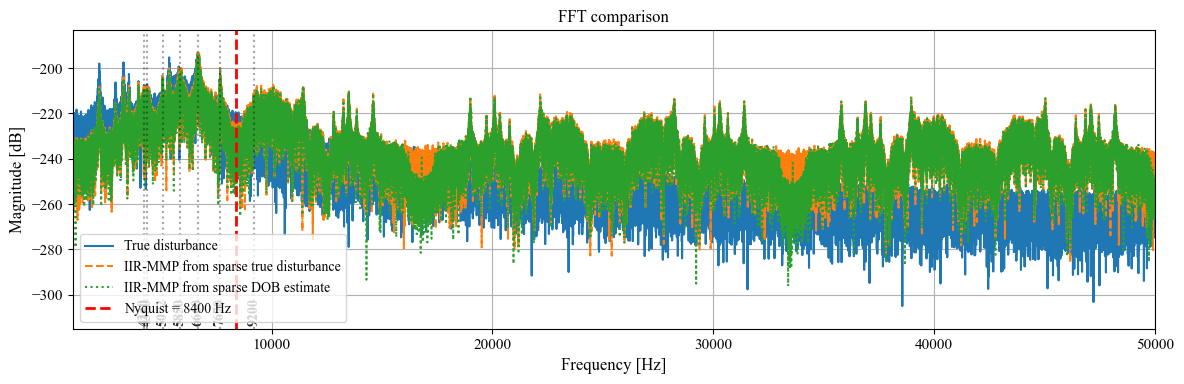

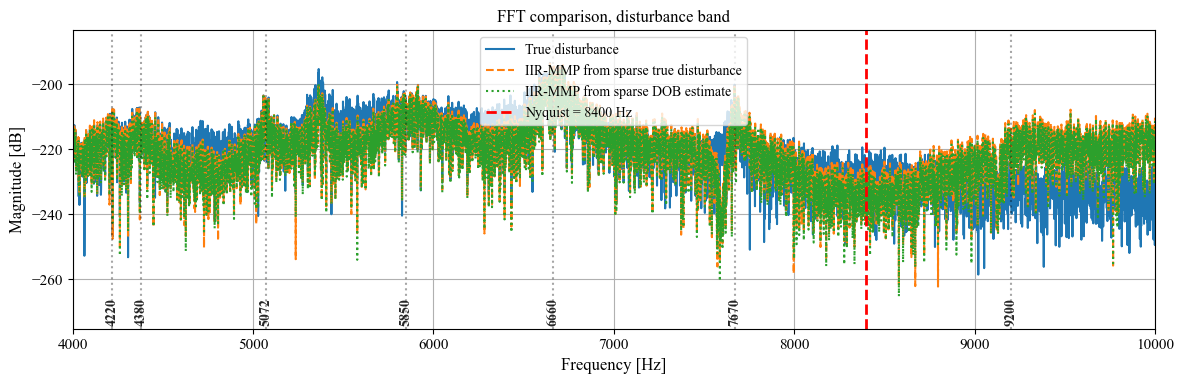

In [77]:
plot_mask_mmp, plot_window_mmp = make_time_mask(
    t_mmp,
    start=T_PLOT_START,
    duration=T_PLOT_DURATION
)
print(f"MMP plot window = [{plot_window_mmp[0]:.6f}, {plot_window_mmp[1]:.6f}] s")
plot_xlim = [plot_window[0], plot_window[1]]

# Time-domain reconstruction comparison
plt.figure(figsize=(12, 4))
plt.plot(t_mmp[plot_mask_mmp], d_p_ref[plot_mask_mmp], label='True disturbance')
plt.plot(t_mmp[plot_mask_mmp], dp_mmp[plot_mask_mmp], '--', label='IIR-MMP from sparse true disturbance')
plt.plot(t_mmp[plot_mask_mmp], dhat_mmp[plot_mask_mmp], ':', label='IIR-MMP from sparse DOB estimate')
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.xlim(plot_xlim)
plt.tight_layout()
plt.show()

# plotting slow input for the MMP
# MMP input and output using DOB estimate

# MMP input: high-pass DOB estimate downsampled by L_mmp
dhat_mmp_input = dhat_p_hp_ref[::L_MMP]
t_mmp_input = t_mmp[::L_MMP][:len(dhat_mmp_input)]

# Plot masks
plot_mask_mmp = (t_mmp >= plot_xlim[0]) & (t_mmp <= plot_xlim[1])
plot_mask_input = (t_mmp_input >= plot_xlim[0]) & (t_mmp_input <= plot_xlim[1])

plt.figure(figsize=(12, 4))
# Fast-rate high-pass DOB estimate
plt.plot(
    t_mmp[plot_mask_mmp],
    dhat_p_hp_ref[plot_mask_mmp],
    label='High-pass DOB estimate',
    alpha=0.9
)
# Sparse MMP input as stairs
plt.step(
    t_mmp_input[plot_mask_input],
    dhat_mmp_input[plot_mask_input],
    where='post',
    linewidth=1,
    label=f'MMP input: downsampled DOB estimate, L={L_MMP}'
)
# MMP reconstructed output
plt.plot(
    t_mmp[plot_mask_mmp],
    dhat_mmp[plot_mask_mmp],
    ':',
    linewidth=2,
    label='IIR-MMP from sparse DOB estimate'
)
plt.grid(True)
plt.legend()
plt.xlabel('Time [s]')
plt.ylabel('Disturbance')
plt.xlim(plot_xlim)
plt.tight_layout()
if FAN_NOISE_TYPE == "sinusoidal":
    save_current_figure('case1_mmp_dob_input_output.pdf')
else:
    save_current_figure('case2_mmp_dob_input_output.pdf')
plt.show()

# FFTs computed on steady-state data
freq, mag_dp_db = fft_mag_db(d_p_ref[ss_mask], FS_FAST)
_, mag_mmp_dp_db = fft_mag_db(dp_mmp[ss_mask], FS_FAST)
_, mag_mmp_dhat_db = fft_mag_db(dhat_mmp[ss_mask], FS_FAST)

# finding min and max magnitudes within the specified range
idx_band = (freq >= np.min(FFT_XLIM_ZOOM)) & (freq <= np.max(FFT_XLIM_ZOOM))
mag_band = np.concatenate([mag_mmp_dp_db[idx_band], mag_mmp_dhat_db[idx_band],mag_dp_db[idx_band]])
FFT_YLIM_ZOOM = [np.min(mag_band)-10, np.max(mag_band)+10]

idx_all = (freq >= np.min(FFT_XLIM_FULL)) & (freq <= np.max(FFT_XLIM_FULL))
mag_all = np.concatenate([mag_mmp_dp_db[idx_all], mag_mmp_dhat_db[idx_all],mag_dp_db[idx_all]])
FFT_YLIM = [np.min(mag_all)-10, np.max(mag_all)+10]

# Full frequency-range FFT
plt.figure(figsize=(12, 4))
plt.plot(freq, mag_dp_db, label='True disturbance')
plt.plot(freq, mag_mmp_dp_db, '--', label='IIR-MMP from sparse true disturbance')
plt.plot(freq, mag_mmp_dhat_db, ':', label='IIR-MMP from sparse DOB estimate')
draw_frequency_lines(F_MMP)
draw_nyquist(F_NYQUIST_SLOW)
plt.grid(True)
plt.legend()
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison')
plt.xlim(FFT_XLIM_FULL)
plt.ylim(FFT_YLIM)
plt.tight_layout()
if FAN_NOISE_TYPE == "sinusoidal":
    save_current_figure('case1_fft_comparison_full_range.pdf')
else:
    save_current_figure('case2_fft_comparison_full_range.pdf')
plt.show()

# Zoomed FFT around disturbance frequencies
plt.figure(figsize=(12, 4))
plt.plot(freq, mag_dp_db, label='True disturbance')
plt.plot(freq, mag_mmp_dp_db, '--', label='IIR-MMP from sparse true disturbance')
plt.plot(freq, mag_mmp_dhat_db, ':', label='IIR-MMP from sparse DOB estimate')
draw_frequency_lines(F_MMP)
draw_nyquist(F_NYQUIST_SLOW)
plt.grid(True)
plt.legend(loc='upper center')
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude [dB]')
plt.title('FFT comparison, disturbance band')
plt.xlim(FFT_XLIM_ZOOM)
plt.ylim(FFT_YLIM_ZOOM)
plt.tight_layout()
if FAN_NOISE_TYPE == "sinusoidal":
    save_current_figure('case1_fft_comparison_disturbance_band.pdf')
else:
    save_current_figure('case2_fft_comparison_disturbance_band.pdf')
plt.show()

## 8. MMP phase-filter Bode plots

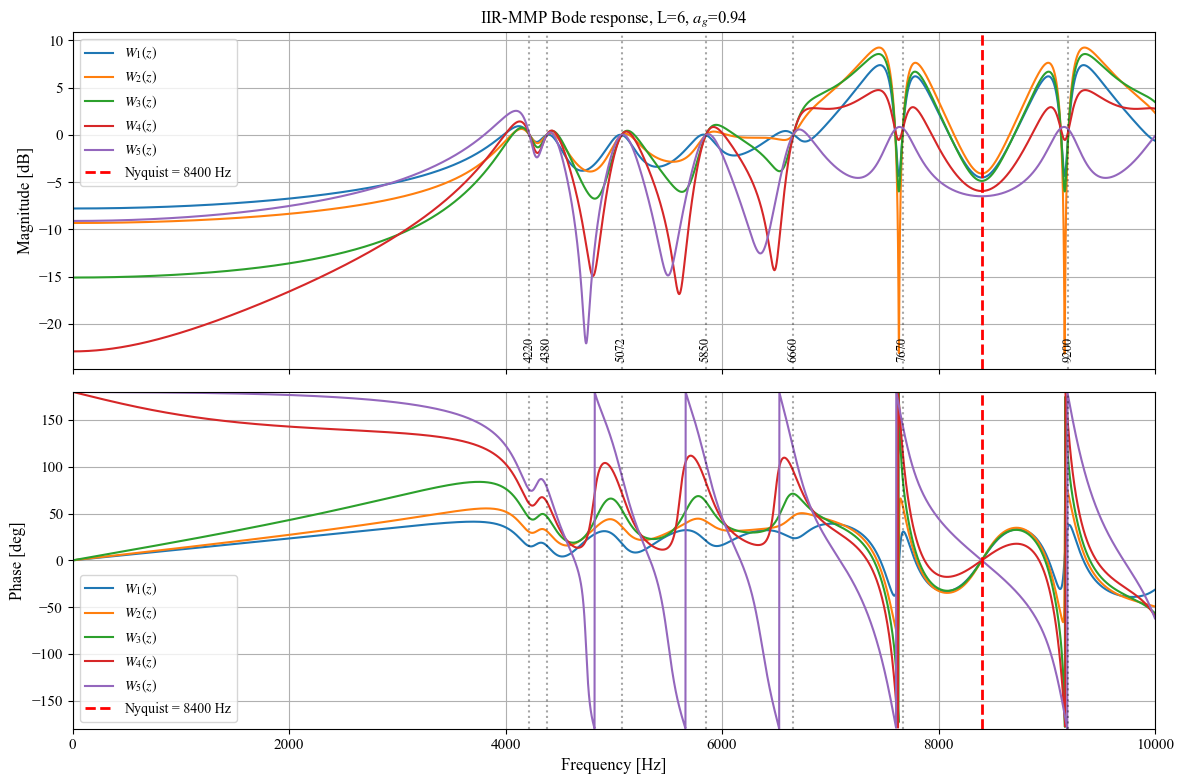

In [79]:
# Each intersample phase has one MMP filter:
# W_k(z) = numerator w_k / denominator Bpara.
a_g = 0.94
TS_SLOW = L_MMP * TS_FAST

w_kiir, Bpara = mmp_coeff(
    f_hz=F_MMP,
    t_fs=TS_FAST,
    a_g=A_G,
    L=L_MMP
)

f_plot = np.linspace(1, BODE_XLIM[1], 5000)
omega = 2 * np.pi * f_plot * TS_SLOW

fig, axs = plt.subplots(
    2,
    1,
    figsize=(12, 8),
    sharex=True
)

ax_mag = axs[0]
ax_phase = axs[1]

# Magnitude and phase response
for k in range(w_kiir.shape[1]):
    b = w_kiir[:, k]
    a = Bpara

    _, H = signal.freqz(b, a, worN=omega)

    mag_db = 20 * np.log10(np.abs(H) + 1e-12)

    phase_deg = np.angle(H, deg=True)
    phase_deg = (phase_deg + 180) % 360 - 180

    ax_mag.plot(
        f_plot,
        mag_db,
        label=f'$W_{k + 1}(z)$'
    )

    ax_phase.plot(
        f_plot,
        phase_deg,
        label=f'$W_{k + 1}(z)$'
    )

# Frequency lines
for fd in F_MMP:
    ax_mag.axvline(fd, color='k', linestyle=':', alpha=0.35)
    ax_phase.axvline(fd, color='k', linestyle=':', alpha=0.35)

    ax_mag.text(
        fd,
        0.02,
        f'{fd:.0f}',
        rotation=90,
        transform=ax_mag.get_xaxis_transform(),
        ha='center',
        va='bottom',
        fontsize=9
    )

# Nyquist line
for ax in axs:
    ax.axvline(
        F_NYQUIST_SLOW,
        color='r',
        linestyle='--',
        linewidth=2,
        label=f'Nyquist = {F_NYQUIST_SLOW:.0f} Hz'
    )

# Magnitude subplot
ax_mag.set_ylabel('Magnitude [dB]')
ax_mag.set_title(f'IIR-MMP Bode response, L={L_MMP}, $a_g$={A_G}')
ax_mag.grid(True)
ax_mag.legend(loc='best')
# Phase subplot
ax_phase.set_xlabel('Frequency [Hz]')
ax_phase.set_ylabel('Phase [deg]')
ax_phase.set_xlim(BODE_XLIM)
ax_phase.set_ylim([-180, 180])
ax_phase.grid(True)
ax_phase.legend(loc='best')

plt.tight_layout()

if FAN_NOISE_TYPE == "sinusoidal":
    save_current_figure('case1_mmp_bode_combined.pdf')
else:
    save_current_figure('case2_mmp_bode_combined.pdf')

plt.show()


## 9. Error Analysis

f= 4220.0 Hz | true amp=8.381e-11 | est amp=7.257e-11 | error=-1.25 dB
f= 4380.0 Hz | true amp=8.793e-11 | est amp=7.397e-11 | error=-1.50 dB
f= 5072.0 Hz | true amp=1.348e-10 | est amp=1.309e-10 | error=-0.26 dB
f= 5850.0 Hz | true amp=1.569e-10 | est amp=1.425e-10 | error=-0.83 dB
f= 6660.0 Hz | true amp=4.298e-10 | est amp=3.845e-10 | error=-0.97 dB
f= 7670.0 Hz | true amp=1.977e-10 | est amp=1.718e-10 | error=-1.22 dB
f= 9200.0 Hz | true amp=1.363e-11 | est amp=4.846e-11 | error=11.02 dB
f= 4220.0 Hz | peak=7.257e-11 | noise floor=2.049e-11 | PNR=10.98 dB
f= 4380.0 Hz | peak=7.397e-11 | noise floor=1.668e-11 | PNR=12.94 dB
f= 5072.0 Hz | peak=1.309e-10 | noise floor=1.780e-11 | PNR=17.33 dB
f= 5850.0 Hz | peak=1.425e-10 | noise floor=3.981e-11 | PNR=11.08 dB
f= 6660.0 Hz | peak=3.845e-10 | noise floor=4.563e-11 | PNR=18.51 dB
f= 7670.0 Hz | peak=1.718e-10 | noise floor=1.418e-11 | PNR=21.67 dB
f= 9200.0 Hz | peak=4.846e-11 | noise floor=1.542e-11 | PNR=9.95 dB
coherence nperseg = 5

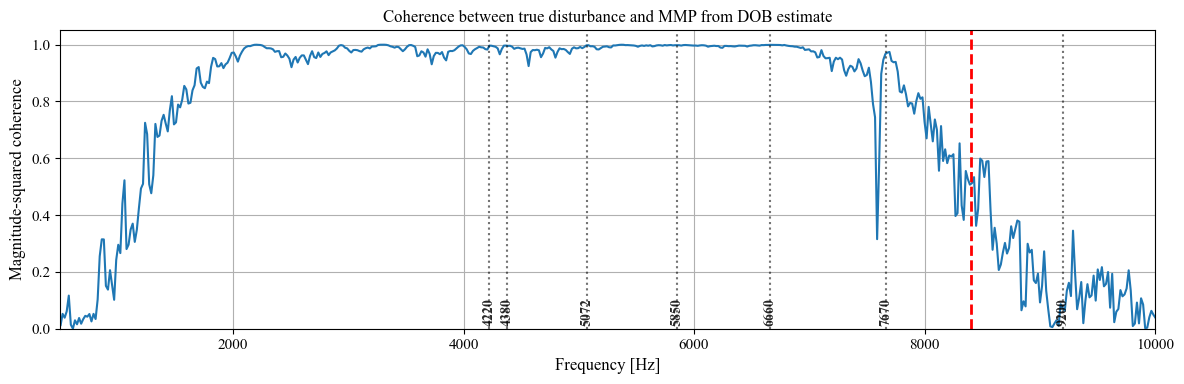

In [83]:
fs_fast = 1 / TS_FAST

f_targets = np.array([4220, 4380, 5072, 5850, 6660, 7670, 9200])

metrics_dp = peak_match_metrics(
    y_true=d_p_ref[ss_mask],
    y_est=dhat_mmp[ss_mask],
    fs=fs_fast,
    f_targets=f_targets,
    band_hz=20
)

metrics_dhat = peak_match_metrics(
    y_true=d_p_ref[ss_mask],
    y_est=dhat_mmp[ss_mask],
    fs=fs_fast,
    f_targets=f_targets,
    band_hz=20
)

for row in metrics_dhat:
    print(
        f"f={row['target_hz']:7.1f} Hz | "
        f"true amp={row['true_amp']:.3e} | "
        f"est amp={row['est_amp']:.3e} | "
        f"error={row['amp_error_db']:.2f} dB"
    )


pnr_true = peak_to_noise_ratio(d_p_ref[ss_mask], fs_fast, f_targets)
pnr_dhat = peak_to_noise_ratio(dhat_mmp[ss_mask], fs_fast, f_targets)

for row in pnr_dhat:
    print(
        f"f={row['target_hz']:7.1f} Hz | "
        f"peak={row['peak_amp']:.3e} | "
        f"noise floor={row['noise_floor']:.3e} | "
        f"PNR={row['pnr_db']:.2f} dB"
    )

nperseg = choose_coherence_nperseg(
    d_p_ref[ss_mask],
    dhat_mmp[ss_mask],
    desired=8192,
    min_segments=17
)

noverlap = nperseg // 2

print("coherence nperseg =", nperseg)
print("number of segments approx =", len(d_p_ref[ss_mask]) // (nperseg - noverlap))

f_coh, coh = signal.coherence(
    d_p_ref[ss_mask],
    dhat_mmp[ss_mask],
    fs=FS_FAST,
    nperseg=nperseg,
    noverlap=noverlap
)

plt.figure(figsize=(12,4))
plt.plot(f_coh, coh)

for fd in F_MMP:
    plt.axvline(fd, color='k', linestyle=':', alpha=0.3)
draw_frequency_lines(F_MMP)
plt.axvline(
    F_NYQUIST_SLOW,
    color='r',
    linestyle='--',
    linewidth=2,
    label=f'Nyquist = {F_NYQUIST_SLOW:.0f} Hz'
)
plt.grid(True)
plt.xlabel('Frequency [Hz]')
plt.ylabel('Magnitude-squared coherence')
plt.title('Coherence between true disturbance and MMP from DOB estimate')
plt.xlim([500, 10000])
plt.ylim([0, 1.05])
plt.tight_layout()
if FAN_NOISE_TYPE == "sinusoidal":
    save_current_figure('case1_coherence.pdf')
else:
    save_current_figure('case2_coherence.pdf')

plt.show()

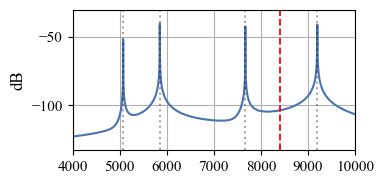

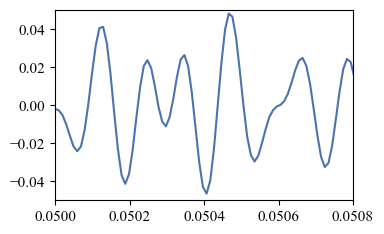

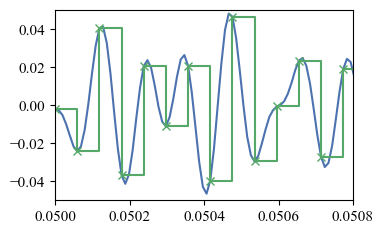

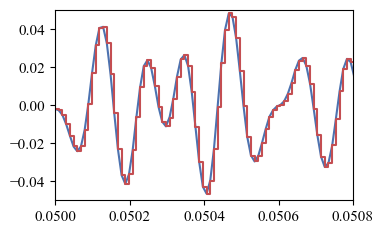

In [57]:
################## plot 1 FFT
plt.figure(figsize=(4, 2))
plt.plot(freq, mag_dp_db,color="#4C72B0",linewidth=1.5)

ax = plt.gca()
for freq_hz in F_MMP:
    ax.axvline(freq_hz, color='k', linestyle=':', alpha=0.35)
    #ax.text(freq_hz,0.01,f'{F_MMP:.0f}',rotation=90,fontsize=10,
    #fontweight='bold',color='k',alpha=0.85,transform=ax.get_xaxis_transform(),ha='center',va='bottom')
ax.axvline(F_NYQUIST_SLOW,color='r',linestyle='--',linewidth=1.3,) #label=f'Nyquist = {F_NYQUIST_SLOW:.0f} Hz')
#ax.text(F_NYQUIST_SLOW,0.01,f'Nyquist',rotation=90,fontsize=10,
#        fontweight='bold',color='k',alpha=0.85,transform=ax.get_xaxis_transform(),ha='center',va='bottom')
plt.grid(True)
plt.ylabel('dB')
plt.xlim(FFT_XLIM_ZOOM)
plt.ylim(FFT_YLIM_ZOOM)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fft_ideal_case.pdf', bbox_inches='tight')
plt.show()

plt_duration = plot_xlim[1] - plot_xlim[0]
plt_acc = [plot_xlim[0], plot_xlim[0] + plt_duration/5]
################## plot 1 signal
plt.figure(figsize=(4, 2.5))
# Fast-rate high-pass DOB estimate
plt.plot(t_mmp[plot_mask_mmp],dhat_p_hp_ref[plot_mask_mmp],color="#4C72B0")
plt.ylim([-0.05, 0.05])
plt.xlim(plt_acc)
plt.tight_layout()
plt.savefig(FIG_DIR / 'signal_ct.pdf', bbox_inches='tight')
plt.show()

################## plot 2, aliased signal
plt.figure(figsize=(4, 2.5))
# Fast-rate high-pass DOB estimate
plt.plot(t_mmp[plot_mask_mmp],dhat_p_hp_ref[plot_mask_mmp],color="#4C72B0")
# Sparse MMP input as stairs
plt.step(t_mmp_input[plot_mask_input],dhat_mmp_input[plot_mask_input],'-x',color='#55A868',where='post',linewidth=1.5)
plt.ylim([-0.05, 0.05])
plt.xlim(plt_acc)
plt.tight_layout()
plt.savefig(FIG_DIR / 'signal_aliased.pdf', bbox_inches='tight')
plt.show()

################## plot 3, constructed signal
plt.figure(figsize=(4, 2.5))
# Fast-rate high-pass DOB estimate
plt.plot(t_mmp[plot_mask_mmp],dhat_p_hp_ref[plot_mask_mmp],color="#4C72B0")
# Sparse MMP input as stairs
#plt.step(t_mmp_input[plot_mask_input],dhat_mmp_input[plot_mask_input],color='#55A868',where='post',linewidth=1.5,)
plt.step(t_mmp[plot_mask_mmp], dhat_mmp[plot_mask_mmp],color='#C44E52',where='post',linewidth=1.5)
plt.ylim([-0.05, 0.05])
plt.xlim(plt_acc)
plt.tight_layout()
plt.savefig(FIG_DIR / 'reconstructed.pdf', bbox_inches='tight')
plt.show()